In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("flight_data_2024_sample.csv", low_memory=False)

In [64]:
print("Dataset shape:", df.shape)

Dataset shape: (10000, 35)


In [65]:
display(df.head())

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [66]:
display(df.describe(include="all").transpose().head(10))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,10000.0,NaN,NaN,NaN,2024.0,0.0,2024.0,2024.0,2024.0,2024.0,2024.0
month,10000.0,NaN,NaN,NaN,6.6132,3.377858,1.0,4.0,7.0,10.0,12.0
day_of_month,10000.0,NaN,NaN,NaN,15.843,8.792774,1.0,8.0,16.0,23.0,31.0
day_of_week,10000.0,NaN,NaN,NaN,3.9502,2.00637,1.0,2.0,4.0,6.0,7.0
fl_date,10000,366,2024-08-09,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_unique_carrier,10000,15,WN,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_carrier_fl_num,10000.0,NaN,NaN,NaN,2529.7626,1655.998442,1.0,1172.0,2254.0,3742.0,8771.0
origin,10000,284,ATL,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_city_name,10000,278,"Chicago, IL",516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_state_nm,10000,52,California,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Average delay statistics**

In [67]:
print("Average Departure Delay (minutes):", df["dep_delay"].mean())

Average Departure Delay (minutes): 13.002428166734116


In [68]:
print("Average Arrival Delay (minutes):", df["arr_delay"].mean())

Average Arrival Delay (minutes): 7.545038633590891


### **Delays by Month**

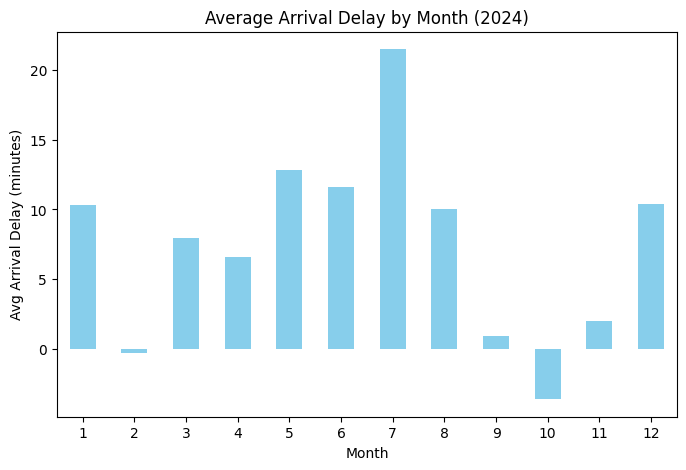

In [69]:
monthly_delay = df.groupby("month")["arr_delay"].mean()

plt.figure(figsize=(8,5))
monthly_delay.plot(kind="bar", color="skyblue")
plt.title("Average Arrival Delay by Month (2024)")
plt.xlabel("Month")
plt.ylabel("Avg Arrival Delay (minutes)")
plt.xticks(rotation=0)
plt.show()


### **Top 10 busiest origin airports**


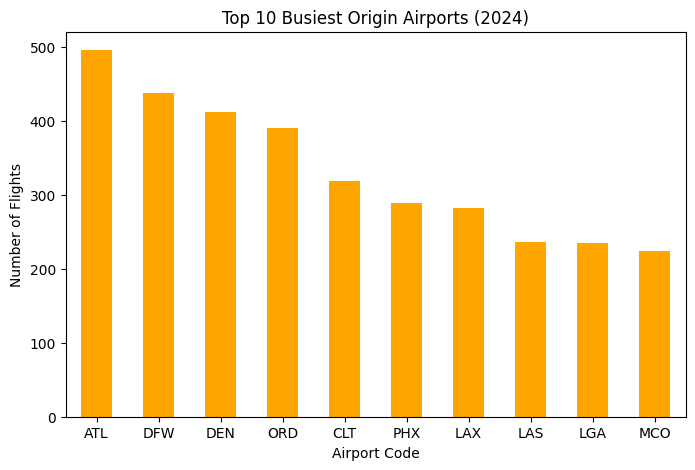

In [70]:
busiest_airports = df["origin"].value_counts().head(10)

plt.figure(figsize=(8,5))
busiest_airports.plot(kind="bar", color="orange")
plt.title("Top 10 Busiest Origin Airports (2024)")
plt.xlabel("Airport Code")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.show()

# **Defining the features**

In [72]:
features = ['year','month','op_unique_carrier','origin_city_name','dest_city_name','dep_time','dep_delay','arr_time','arr_delay','distance']
df = df[features]
df.shape

(10000, 10)

In [73]:
df.head()

,year,month,op_unique_carrier,origin_city_name,dest_city_name,dep_time,dep_delay,arr_time,arr_delay,distance
0,2024,4,MQ,"Dallas/Fort Worth, TX","Rapid City, SD",1015.0,-3.0,1139.0,-10.0,835.0
1,2024,1,AA,"Charlotte, NC","Phoenix, AZ",1633.0,-4.0,1906.0,-17.0,1773.0
2,2024,12,9E,"Chattanooga, TN","Atlanta, GA",952.0,-8.0,1042.0,-17.0,106.0
3,2024,4,WN,"Omaha, NE","Las Vegas, NV",1334.0,4.0,1431.0,1.0,1099.0
4,2024,2,WN,"Baltimore, MD","Myrtle Beach, SC",1333.0,-7.0,1509.0,-1.0,399.0


# **Exploratory Data Analysis**

# **Data Pre Processing**

## **Checking missing values**

In [74]:
# Check missing values per column
df[features].isna().sum()

year                   0
month                  0
op_unique_carrier      0
origin_city_name       0
dest_city_name         0
dep_time             116
dep_delay            116
arr_time             127
arr_delay            164
distance               0
dtype: int64

### **New shape after cleaning**

In [75]:
df = df.dropna(subset=features)
df.shape

(9836, 10)

### **Categorical features Encoding**

In [76]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['op_unique_carrier', 'origin_city_name', 'dest_city_name']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col + '_code'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le  # save encoder to transform new data later

df_encoded = df.drop(columns=cat_cols)
df_encoded.head()


,year,month,dep_time,dep_delay,arr_time,arr_delay,distance,op_unique_carrier_code,origin_city_name_code,dest_city_name_code
0,2024,4,1015.0,-3.0,1139.0,-10.0,835.0,8,62,212
1,2024,1,1633.0,-4.0,1906.0,-17.0,1773.0,1,46,199
2,2024,12,952.0,-8.0,1042.0,-17.0,106.0,0,48,14
3,2024,4,1334.0,4.0,1431.0,1.0,1099.0,13,182,143
4,2024,2,1333.0,-7.0,1509.0,-1.0,399.0,13,20,179


In [77]:
le = LabelEncoder()
carrier_codes = le.fit_transform(df['op_unique_carrier'])

# later, to get back original carrier names:
original_carriers = le.inverse_transform(carrier_codes)
original_carriers

array(['MQ', 'AA', '9E', ..., 'MQ', 'DL', 'G4'], dtype=object)

## **Splitting the dataset into 5 equal Bacthes (chucks)**

In [ ]:
import os

os.makedirs("streaming_input", exist_ok=True)

chunk_size = 2000
for i, start in enumerate(range(0, len(df_encoded), chunk_size)):
    chunk = df_encoded.iloc[start:start + chunk_size]
    chunk.to_csv(f"streaming_input/chunk_{i}.csv", index=False)

print("Chunks created:", len(os.listdir("streaming_input")))

Chunks created: 5


### **Batch (Chunk) shape**

In [5]:
test_df = pd.read_csv("streaming_input/chunk_0.csv")
test_df.shape

(2000, 10)

# **PySpark Libraries Import**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType
from pyspark.sql.functions import when, col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    DecisionTreeClassifier, RandomForestClassifier,
    GBTClassifier, LinearSVC, LogisticRegression
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt

## **Start Spark Session**

In [3]:
spark = SparkSession.builder \
    .appName("FlightDelayStreamingML") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

/usr/local/lib/python3.12/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/05 16:42:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## **Schema for the stream dataframe**

In [4]:
schema = StructType([
    StructField("year",                   IntegerType(), True),
    StructField("month",                  IntegerType(), True),
    StructField("dep_time",               DoubleType(),  True),
    StructField("dep_delay",              DoubleType(),  True),
    StructField("arr_time",               DoubleType(),  True),
    StructField("arr_delay",              DoubleType(),  True),
    StructField("distance",               DoubleType(),  True),
    StructField("op_unique_carrier_code", IntegerType(), True),
    StructField("origin_city_name_code",  IntegerType(), True),
    StructField("dest_city_name_code",    IntegerType(), True),
])

### **Read stream from the folder (to simulate live data)**

In [5]:
path_to_folder = "streaming_input"

stream_df = spark.readStream \
    .schema(schema) \
    .option("header", True) \
    .csv(path_to_folder)

### **Feature columns for PySpark**

In [6]:
feature_cols = [
    "year", "month", "dep_time", "dep_delay", "arr_time",
    "distance", "op_unique_carrier_code",
    "origin_city_name_code", "dest_city_name_code"
]
label_col = "IsDelayed"

## **Helper Functions**

### **Evaluate Function with 5 Metrics & History Dict for plots**

In [7]:
history = {}
def evaluate_model(preds, label_col, model_name, batch_id):
    acc_eval  = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol="prediction", metricName="accuracy")
    f1_eval   = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol="prediction", metricName="f1")
    prec_eval = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol="prediction", metricName="weightedPrecision")
    rec_eval  = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol="prediction", metricName="weightedRecall")

    acc  = acc_eval.evaluate(preds)
    f1   = f1_eval.evaluate(preds)
    prec = prec_eval.evaluate(preds)
    rec  = rec_eval.evaluate(preds)

    print(f"\n--- {model_name} ---")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")

    auc = None
    if "rawPrediction" in preds.columns:
        auc_eval = BinaryClassificationEvaluator(labelCol=label_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")
        auc = auc_eval.evaluate(preds)
        print(f"  AUC:       {auc:.4f}")

    # Initialize list for this model if not present
    if model_name not in history:
        history[model_name] = []

    # Append metrics for this batch
    history[model_name].append({
        "batch_id": batch_id,
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec,
        "auc": auc
    })

### **History Processing for Visuals**

In [ ]:
# converting history to pandas dataframe
def history_to_df(history):
    rows = []
    for model_name, entries in history.items():
        for e in entries:
            row = {"model": model_name}
            row.update(e)
            rows.append(row)
    return pd.DataFrame(rows)

### **Train and Evaluate Batch**

In [ ]:
def train_and_evaluate_batch(batch_df, batch_id):
    print(f"\n{'='*50}")
    print(f"Batch ID: {batch_id} | Rows: {batch_df.count()}")

    # creates IsDelayed feature, 1 if delayed, 0 otherwise
    
    batch_df = batch_df.withColumn(
        label_col, when(col("arr_delay") >= 15, 1).otherwise(0)
    )
    batch_df = batch_df.dropna(subset=feature_cols + [label_col])

    if batch_df.count() < 10:
        print(f"Batch {batch_id} too small, skipping.")
        return

    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    ml_df = assembler.transform(batch_df).select("features", label_col)
    train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)

    # Decision Tree
    dt = DecisionTreeClassifier(labelCol=label_col, featuresCol="features", maxDepth=5)
    evaluate_model(dt.fit(train_df).transform(test_df), label_col, "Decision Tree", batch_id)

    # Random Forest
    rf = RandomForestClassifier(labelCol=label_col, featuresCol="features", numTrees=50, maxDepth=5, seed=42)
    evaluate_model(rf.fit(train_df).transform(test_df), label_col, "Random Forest", batch_id)

    # Gradient Boosted Trees
    gbt = GBTClassifier(labelCol=label_col, featuresCol="features", maxIter=20, maxDepth=5, seed=42)
    evaluate_model(gbt.fit(train_df).transform(test_df), label_col, "GBT", batch_id)

    # Linear SVC
    svc = LinearSVC(labelCol=label_col, featuresCol="features", maxIter=10)
    evaluate_model(svc.fit(train_df).transform(test_df), label_col, "LinearSVC", batch_id)

    # Logistic Regression
    lr = LogisticRegression(labelCol=label_col, featuresCol="features",
                            maxIter=20)
    lr_preds = lr.fit(train_df).transform(test_df)
    evaluate_model(lr_preds, label_col, "LogisticRegression", batch_id)


### **Start streaming query**

In [10]:
query = stream_df.writeStream \
    .outputMode("append") \
    .foreachBatch(train_and_evaluate_batch) \
    .start()

query.awaitTermination(timeout=60)  # stops after 30 seconds
#query.awaitTermination()  # stops after 30 seconds
query.stop()
print("Stream finished!")

26/05/05 16:42:17 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-99c86a0f-f28f-4fb1-83d5-283f14110f62. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/05/05 16:42:17 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.



Batch ID: 0 | Rows: 2000

--- Decision Tree ---
  Accuracy:  0.9134
  F1:        0.9107
  Precision: 0.9106
  Recall:    0.9134
  AUC:       0.7534

--- Random Forest ---
  Accuracy:  0.9190
  F1:        0.9159
  Precision: 0.9167
  Recall:    0.9190
  AUC:       0.8993


26/05/05 16:42:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS



--- GBT ---
  Accuracy:  0.9162
  F1:        0.9128
  Precision: 0.9138
  Recall:    0.9162
  AUC:       0.9060

--- LinearSVC ---
  Accuracy:  0.9274
  F1:        0.9239
  Precision: 0.9266
  Recall:    0.9274
  AUC:       0.9162

--- LogisticRegression ---
  Accuracy:  0.9134
  F1:        0.9118
  Precision: 0.9111
  Recall:    0.9134
  AUC:       0.9166

Batch ID: 1 | Rows: 2000

--- Decision Tree ---
  Accuracy:  0.9106
  F1:        0.9085
  Precision: 0.9083
  Recall:    0.9106
  AUC:       0.6999

--- Random Forest ---
  Accuracy:  0.9385
  F1:        0.9353
  Precision: 0.9416
  Recall:    0.9385
  AUC:       0.9028

--- GBT ---
  Accuracy:  0.9218
  F1:        0.9181
  Precision: 0.9217
  Recall:    0.9218
  AUC:       0.9122

--- LinearSVC ---
  Accuracy:  0.9385
  F1:        0.9357
  Precision: 0.9404
  Recall:    0.9385
  AUC:       0.9221

--- LogisticRegression ---
  Accuracy:  0.9330
  F1:        0.9302
  Precision: 0.9333
  Recall:    0.9330
  AUC:       0.9233

Batch I

### **History of all the models across the batches**

In [11]:
df_hist = history_to_df(history)
df_hist.head(25)

,model,batch_id,accuracy,f1,precision,recall,auc
0,Decision Tree,0,0.913408,0.910700,0.910632,0.913408,0.753425
1,Decision Tree,1,0.910615,0.908467,0.908331,0.910615,0.699915
2,Decision Tree,2,0.927374,0.924784,0.926498,0.927374,0.853822
3,Decision Tree,3,0.930168,0.929618,0.929258,0.930168,0.715645
4,Decision Tree,4,0.925000,0.924508,0.924125,0.925000,0.818269
5,Random Forest,0,0.918994,0.915939,0.916712,0.918994,0.899255
6,Random Forest,1,0.938547,0.935290,0.941582,0.938547,0.902839
7,Random Forest,2,0.921788,0.917042,0.923730,0.921788,0.889006
8,Random Forest,3,0.930168,0.927065,0.929349,0.930168,0.925595
9,Random Forest,4,0.931250,0.930799,0.930459,0.931250,0.908397


### **Plots functions**

In [ ]:
def plot_metric_over_batches(df_hist, metric="accuracy"):
    for model_name, g in df_hist.groupby("model"):
        plt.plot(g["batch_id"], g[metric], marker="o", label=model_name)
    
    
    plt.xlabel("Batch ID")
    plt.ylabel(metric.capitalize())
    plt.title(f"{metric.capitalize()} over batches")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_avg_metric_bar(history, metric="accuracy", save_path=None):

    import pandas as pd

    # Flatten history to DataFrame
    rows = []
    for model_name, entries in history.items():
        for e in entries:
            rows.append({"model": model_name, **e})
    df = pd.DataFrame(rows)

    # Average metric per model
    avg = df.groupby("model")[metric].mean().dropna().sort_values(ascending=False)
    models = avg.index.tolist()
    values = avg.values.tolist()

    # Y axis zoom
    y_min = max(0.0, min(values) - 0.01)
    y_max = min(1.0, max(values) + 0.015)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(models, values, color="#4C72B0", edgecolor="white", linewidth=0.8, width=0.55)

    # Value labels above each bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0008,
            f"{val:.4f}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold"
        )

    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(f"Avg {metric.capitalize()}", fontsize=12)
    ax.set_title(f"Average {metric.capitalize()} per Model (all batches)", fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()

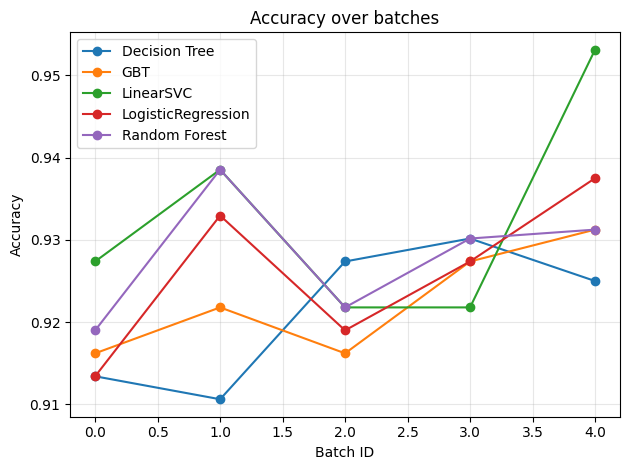

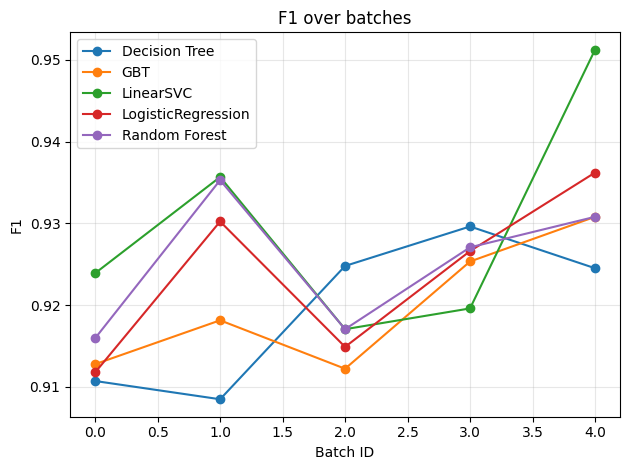

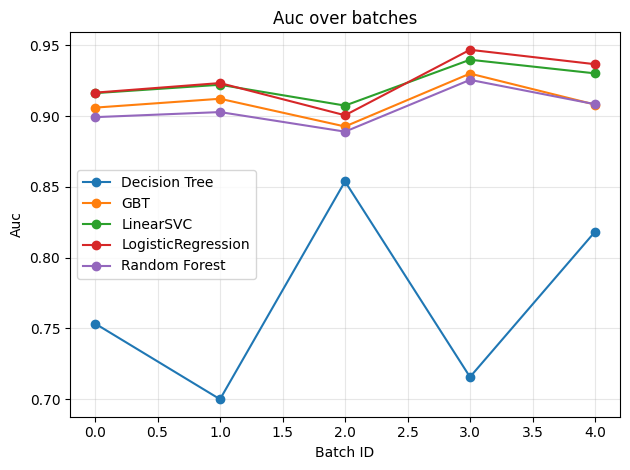

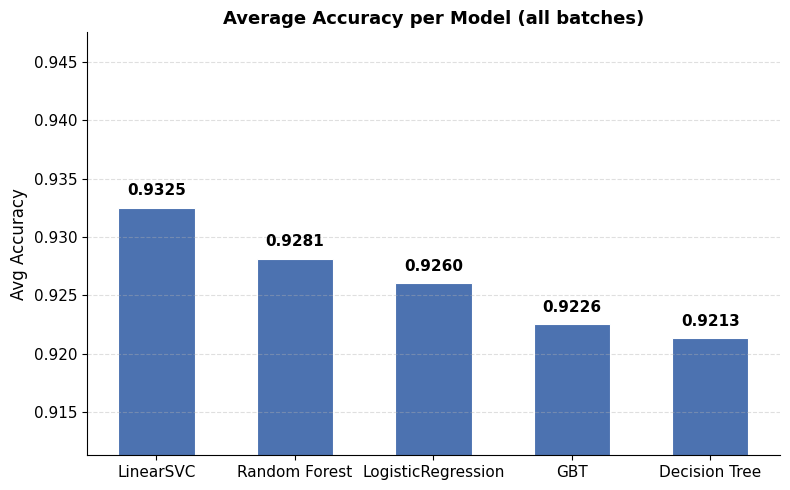

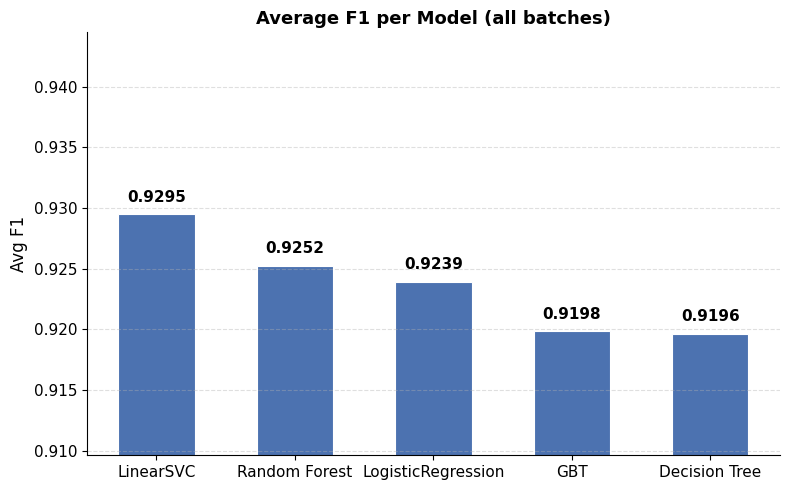

Saved to auc_bar.png


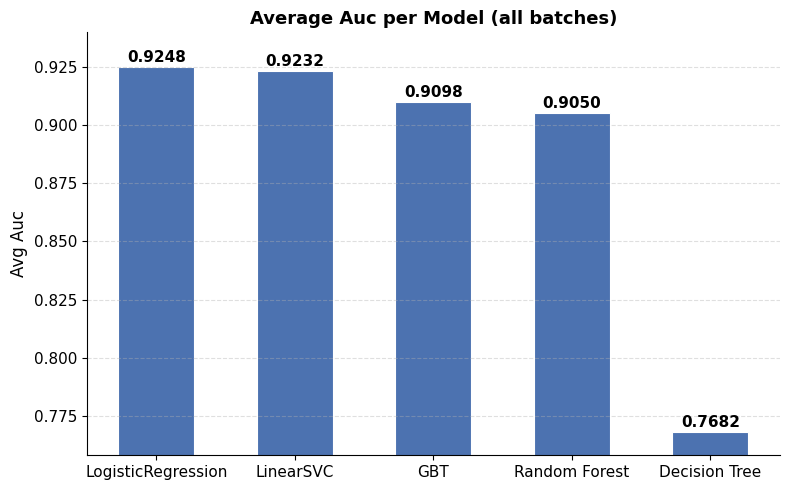

Saved to precision_bar.png


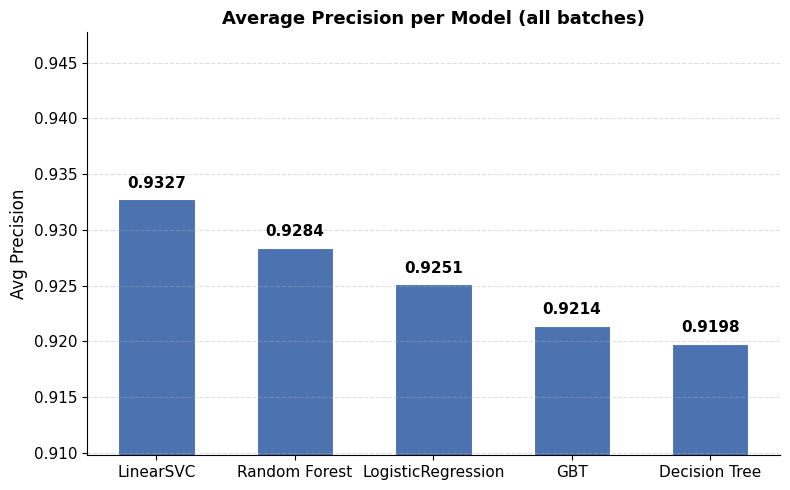

Saved to recall_bar.png


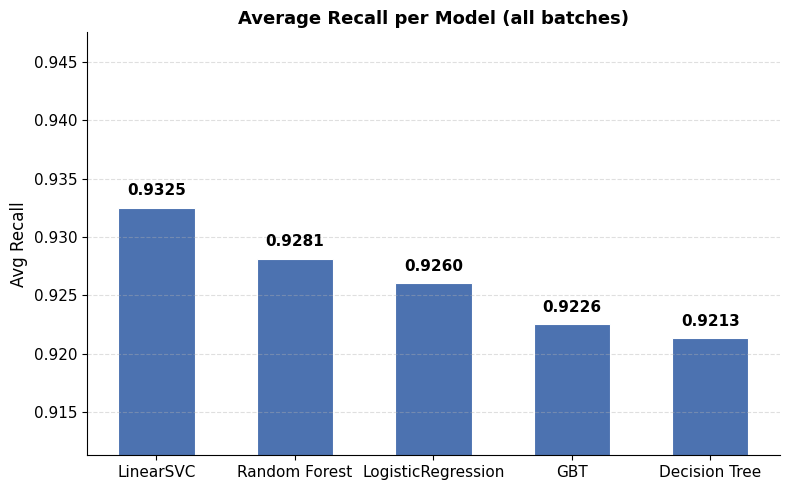

In [14]:
plot_metric_over_batches(df_hist, "accuracy")
plot_metric_over_batches(df_hist, "f1")
plot_metric_over_batches(df_hist, "auc")

#=======================

plot_avg_metric_bar(history, metric="accuracy")
plot_avg_metric_bar(history, metric="f1")
plot_avg_metric_bar(history, metric="auc",       save_path="auc_bar.png")
plot_avg_metric_bar(history, metric="precision", save_path="precision_bar.png")
plot_avg_metric_bar(history, metric="recall",    save_path="recall_bar.png")